<a href="https://colab.research.google.com/github/gilangf03/Tugas-Pertemuan4/blob/main/UTS_Viskom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

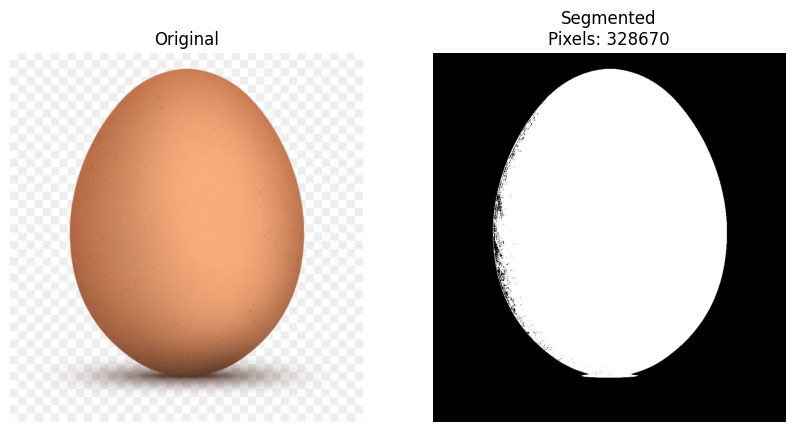

=== HASIL ANALISIS ===
Jumlah Pixel : 328670
Estimasi Bobot : 584.37 gram
Kategori : BESAR (A)


In [4]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression

# =========================
# 1. DATA TRAINING (CONTOH)
# =========================
# x = jumlah pixel
# y = bobot (gram)
# (ini contoh data dummy, kamu bisa ganti dengan data asli)
x_train = np.array([12000, 15000, 18000, 20000, 23000, 26000, 30000]).reshape(-1, 1)
y_train = np.array([40, 45, 50, 55, 60, 65, 70])

model = LinearRegression()
model.fit(x_train, y_train)

# =========================
# 2. FUNGSI KLASIFIKASI
# =========================
def classify_egg(pixel_count):
    predicted_weight = model.predict(np.array([[pixel_count]]))[0]

    if predicted_weight > 60:
        label = "BESAR (A)"
    elif 50 <= predicted_weight <= 60:
        label = "SEDANG (B)"
    else:
        label = "KECIL (C)"

    return predicted_weight, label

# =========================
# 3. PROSES GAMBAR
# =========================
def process_egg_image(image_path):
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Gambar tidak ditemukan, cek path!")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Normalisasi RGB
    sum_rgb = np.sum(img.astype(float), axis=2)
    sum_rgb[sum_rgb == 0] = 1

    norm_r = img[:,:,2] / sum_rgb
    norm_g = img[:,:,1] / sum_rgb

    # Masking telur
    mask = np.logical_and(norm_r >= 0.41, norm_g >= 0.3)
    binary_img = np.where(mask, 255, 0).astype(np.uint8)

    # Hitung pixel objek
    pixel_count = np.sum(binary_img == 255)

    # Prediksi
    weight, category = classify_egg(pixel_count)

    # =========================
    # VISUALISASI
    # =========================
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(img_rgb)
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title(f"Segmented\nPixels: {pixel_count}")
    plt.imshow(binary_img, cmap='gray')
    plt.axis('off')

    plt.show()

    print("=== HASIL ANALISIS ===")
    print(f"Jumlah Pixel : {pixel_count}")
    print(f"Estimasi Bobot : {weight:.2f} gram")
    print(f"Kategori : {category}")

# =========================
# 4. JALANKAN
# =========================
process_egg_image('telur.jpg')